In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("loan_data.csv")
df.shape

ModuleNotFoundError: No module named 'pandas'

In [2]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## checking datatypes and missing values

In [3]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

No missing values in this dataset — it's already clean, which is one advantage over the original
614-row Loan Prediction dataset used earlier in this course.

## Outliers check

In [4]:
print("Age range:", df['person_age'].min(), "-", df['person_age'].max())
print("Applicants older than 80:", (df['person_age'] > 80).sum())
df[df['person_age'] > 80][['person_age','person_income','person_emp_exp','loan_status']].head()

Age range: 20.0 - 144.0
Applicants older than 80: 9


,person_age,person_income,person_emp_exp,loan_status
81,144.0,300616.0,125,0
183,144.0,241424.0,121,0
575,123.0,97140.0,101,0
747,123.0,94723.0,100,0
32297,144.0,7200766.0,124,0


The dataset's documentation flags a known data-quality issue, a small number of applicants have
extreme ages

## Target variable distribution

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


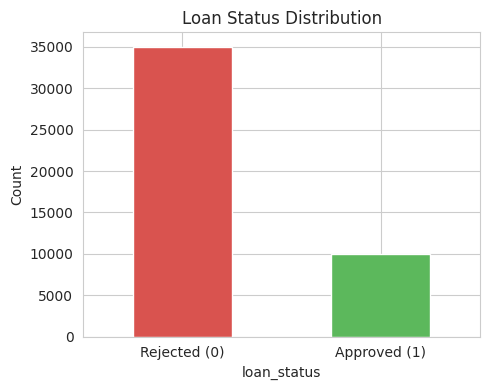

In [5]:
status_counts = df['loan_status'].value_counts(normalize=True) * 100
print(status_counts)

fig, ax = plt.subplots(figsize=(5,4))
df['loan_status'].value_counts().plot(kind='bar', color=['#d9534f','#5cb85c'], ax=ax)
ax.set_xticklabels(['Rejected (0)', 'Approved (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Loan Status Distribution')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120)
plt.show()

In [6]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


## Numeric Features vs. Loan Status

/tmp/ipykernel_132/515932107.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Rejected','Approved'])
/tmp/ipykernel_132/515932107.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Rejected','Approved'])
/tmp/ipykernel_132/515932107.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Rejected','Approved'])


/tmp/ipykernel_132/515932107.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Rejected','Approved'])
/tmp/ipykernel_132/515932107.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Rejected','Approved'])
/tmp/ipykernel_132/515932107.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Rejected','Approved'])


/tmp/ipykernel_132/515932107.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Rejected','Approved'])


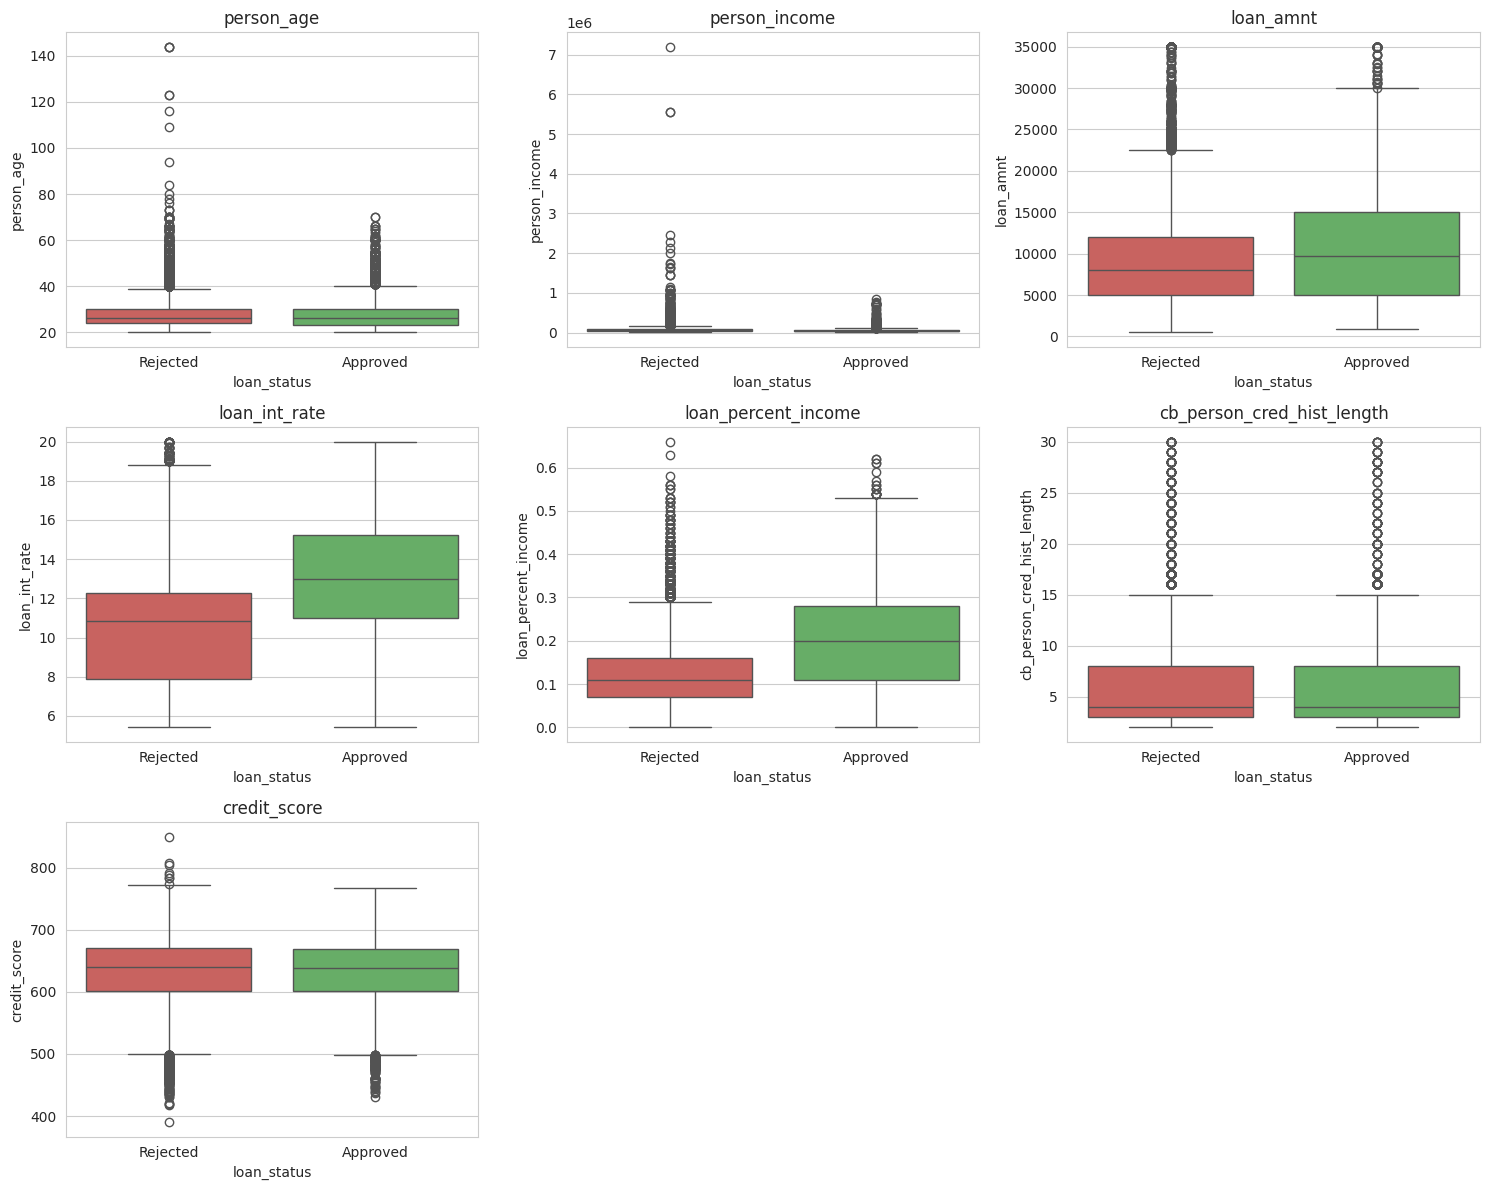

In [7]:
numeric_cols = ['person_age','person_income','loan_amnt','loan_int_rate',
                'loan_percent_income','cb_person_cred_hist_length','credit_score']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='loan_status', y=col, ax=axes[i], hue='loan_status',
                palette=['#d9534f','#5cb85c'], legend=False)
    axes[i].set_xticklabels(['Rejected','Approved'])
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('numeric_vs_status.png', dpi=120)
plt.show()

**Observations:**
- `loan_percent_income` is visibly higher for rejected applications — borrowers requesting a larger
  share of their income are riskier.
- `loan_int_rate` tends to be higher for rejected loans.
- `person_income` is lower, on average, for rejected applicants.
- `credit_score` shows overlapping distributions — a weaker standalone signal than in the previous
  (smaller) dataset, where `Credit_History` was dominant.

## 6. Categorical Features vs. Loan Status

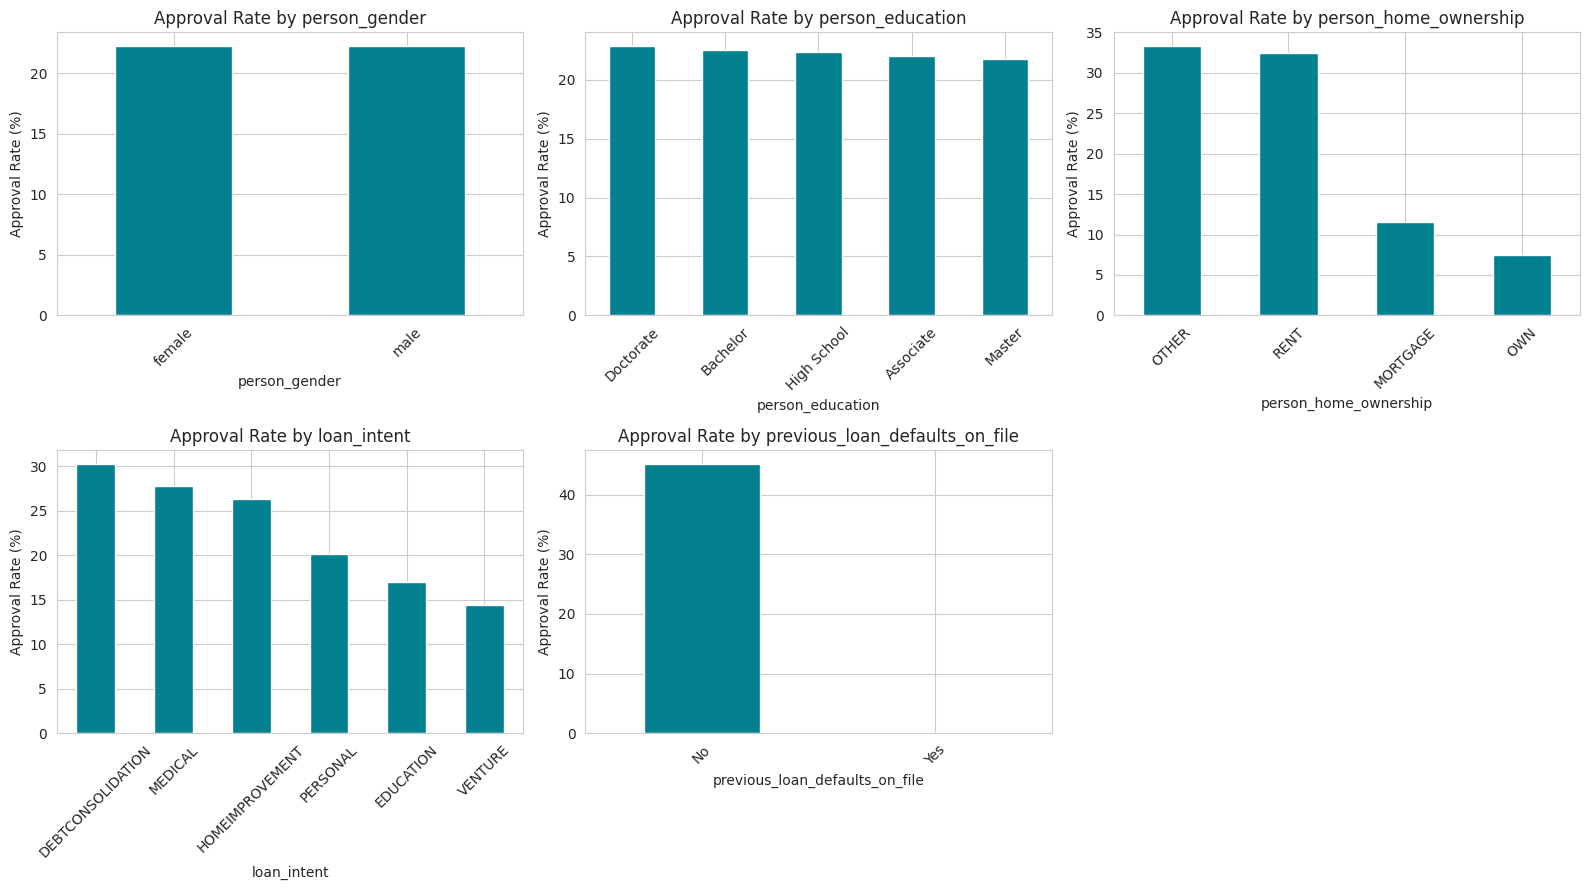

In [8]:
cat_cols = ['person_gender','person_education','person_home_ownership',
            'loan_intent','previous_loan_defaults_on_file']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rates = df.groupby(col)['loan_status'].mean().sort_values(ascending=False) * 100
    rates.plot(kind='bar', ax=axes[i], color='#028090')
    axes[i].set_title(f'Approval Rate by {col}')
    axes[i].set_ylabel('Approval Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('categorical_vs_status.png', dpi=120)
plt.show()

**Observations:**
- `previous_loan_defaults_on_file` shows a large gap — applicants with no prior default history are
  approved far more often, similar to the role `Credit_History` played in the smaller dataset.
- `loan_intent` shows some variation — e.g., debt consolidation / medical loans may have different
  approval rates than venture or personal loans.
- `person_home_ownership` and `person_education` show smaller but visible differences.

## 7. Correlation Matrix (Numeric Features)

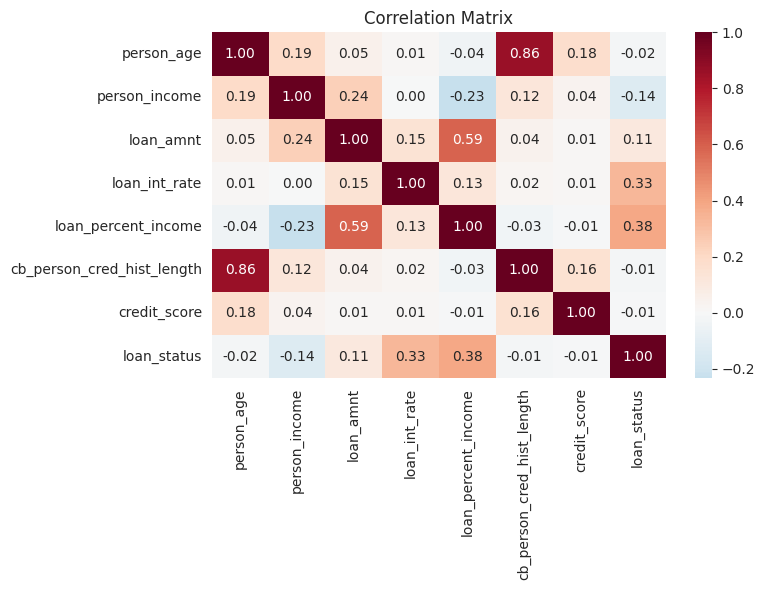

In [9]:
corr = df[numeric_cols + ['loan_status']].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120)
plt.show()

**Observation:** `loan_percent_income` and `loan_int_rate` show the strongest (negative) correlation
with `loan_status` among numeric features, consistent with the boxplots above. No pair of predictors
is highly collinear (|r| > 0.8), so multicollinearity is not a major concern for logistic regression.

## 8. Summary of EDA Findings

1. **No missing data**, but a small number of implausible ages (>100) should be capped.
2. **Target is imbalanced** (~22% approved) — precision/recall and confusion matrix matter more than
   raw accuracy.
3. **Strongest apparent predictors:** `previous_loan_defaults_on_file`, `loan_percent_income`,
   `loan_int_rate`, and `person_income`.
4. **Credit score** is a weaker standalone signal here than in the smaller dataset.
5. No severe multicollinearity among numeric predictors.

Next step: see `02_Modeling.ipynb` for preprocessing, logistic regression modeling, and evaluation.
